# Telco Customer Churn Prediction

**Graduation Project — Machine Learning**

This notebook builds a complete, end-to-end machine learning pipeline to predict
customer churn for a telecommunications company, using the **IBM Telco Customer
Churn** dataset (`WA_Fn-UseC_-Telco-Customer-Churn.csv`).

Only the real, provided dataset is used throughout this notebook — no synthetic
or generated data is introduced at any stage.

## Contents
1. Imports & Setup
2. Data Loading
3. Data Exploration
4. Missing Values
5. Duplicate Handling
6. Data Cleaning
7. Exploratory Data Analysis (EDA)
8. Outlier Analysis
9. Target Encoding
10. Train / Test Split
11. Preprocessing (Encoding + Scaling)
12. Feature Selection
13. Cross-Validation & Model Comparison
14. Hyperparameter Tuning (GridSearchCV)
15. Final Model Evaluation (Confusion Matrix, ROC, Precision-Recall, Classification Report)
16. Feature Importance
17. Saving the Model & Preprocessor
18. Conclusion


## 1. Imports & Setup

In [55]:
RANDOM_STATE = 42

In [56]:
import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Feature Selection
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import SelectFromModel

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier

# Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
from sklearn.metrics import ConfusionMatrixDisplay

# Save Model
import joblib

In [57]:

from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import RandomizedSearchCV

## 2. Data Loading

We load the original, unmodified CSV file provided for this project.

In [58]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [59]:
print("Shape:", df.shape)


Shape: (7043, 21)


## 3. Data Exploration

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [61]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [62]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [63]:
print("Target variable: Churn")
print(df['Churn'].value_counts())
print()
print(df['Churn'].value_counts(normalize=True).round(4) * 100, "%")

Target variable: Churn
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64 %


**Observations:**
- 7,043 customer records, 21 columns.
- `customerID` is a unique identifier for every row and carries no predictive signal — it will be dropped.
- `TotalCharges` is stored as text (`object`) instead of numeric — this needs correction.
- The target `Churn` is imbalanced: about **73.5% "No"** vs **26.5% "Yes"**. This is handled later using
  `class_weight='balanced'` in the models rather than synthetic oversampling, since only real data is permitted.

## 4. Missing Values

In [64]:
print("Null values per column:")
print(df.isnull().sum())
print()
print("Total nulls:", df.isnull().sum().sum())

Null values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total nulls: 0


In [65]:
# TotalCharges is stored as a string. Convert to numeric and inspect what becomes NaN.
tc_numeric_check = pd.to_numeric(df['TotalCharges'], errors='coerce')
missing_mask = tc_numeric_check.isnull()
print("Rows where TotalCharges cannot be parsed as numeric:", missing_mask.sum())
df.loc[missing_mask, ['tenure', 'MonthlyCharges', 'TotalCharges']]

Rows where TotalCharges cannot be parsed as numeric: 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,
753,0,20.25,
936,0,80.85,
1082,0,25.75,
1340,0,56.05,
3331,0,19.85,
3826,0,25.35,
4380,0,20.00,
5218,0,19.70,
6670,0,73.35,


In [66]:
print(missing_mask.sum())

11


All 11 problematic rows correspond to customers with `tenure == 0`, i.e. brand-new
customers who have not yet been billed. These are legitimate real records, not corrupted
data, so we fix the type and fill these 11 values with `0` (consistent with zero tenure and
no billing history yet) rather than dropping the rows.

In [67]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

## 5. Duplicate Handling

In [68]:
df.drop_duplicates(inplace=True)

In [69]:
print("Fully duplicated rows (all columns identical):", df.duplicated().sum())
print("Duplicated rows ignoring customerID:", df.drop(columns=['customerID']).duplicated().sum())

Fully duplicated rows (all columns identical): 0
Duplicated rows ignoring customerID: 22


There are no fully duplicated rows. When `customerID` is ignored, 22 rows share
identical attribute combinations with another row — but since `customerID` is unique for
every one of the 7,043 records, these represent **different real customers who happen to
share the same attribute profile**, not duplicate entries of the same customer. We therefore
keep all rows; removing them would discard genuine observations.

## 6. Data Cleaning

In [70]:
# Fix TotalCharges dtype and fill the 11 zero-tenure customers with 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# customerID carries no predictive value
df = df.drop(columns=['customerID'])

print(df.dtypes)
print()
print("Missing values after cleaning:", df.isnull().sum().sum())

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Missing values after cleaning: 0


## 7. Exploratory Data Analysis (EDA)

We visualize the target distribution, churn rate across key categorical drivers,
and the shape/relationships of the numeric features.

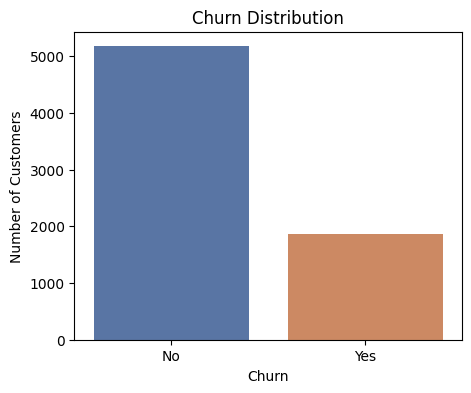

In [71]:
plt.figure(figsize=(5, 4))
sns.countplot(x='Churn', data=df, palette=['#4C72B0', '#DD8452'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

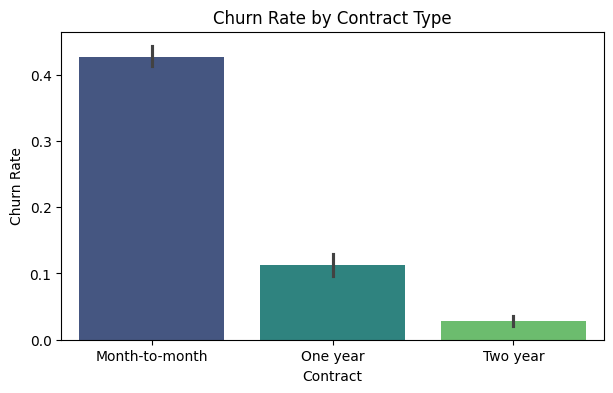

In [72]:
plt.figure(figsize=(7, 4))
sns.barplot(x='Contract', y=(df['Churn'] == 'Yes').astype(int), data=df, estimator=np.mean, palette='viridis')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Contract Type')
plt.show()

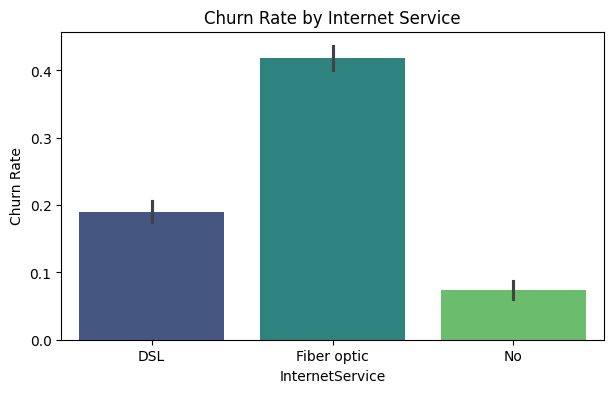

In [73]:
plt.figure(figsize=(7, 4))
sns.barplot(x='InternetService', y=(df['Churn'] == 'Yes').astype(int), data=df, estimator=np.mean, palette='viridis')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Internet Service')
plt.show()

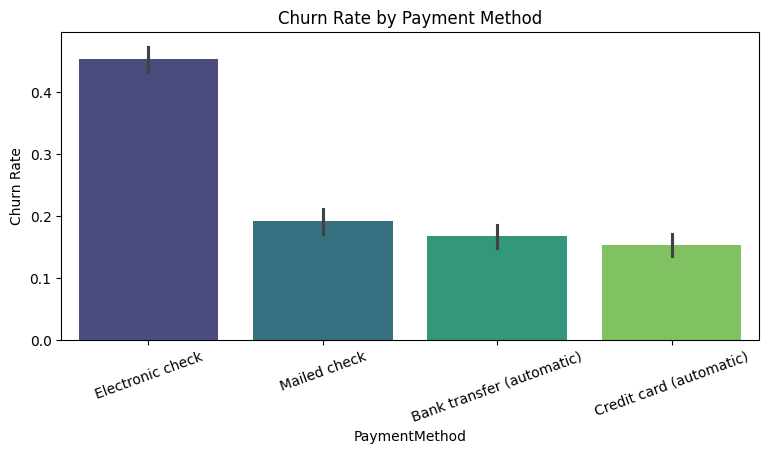

In [74]:
plt.figure(figsize=(9, 4))
sns.barplot(x='PaymentMethod', y=(df['Churn'] == 'Yes').astype(int), data=df, estimator=np.mean, palette='viridis')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Payment Method')
plt.xticks(rotation=20)
plt.show()

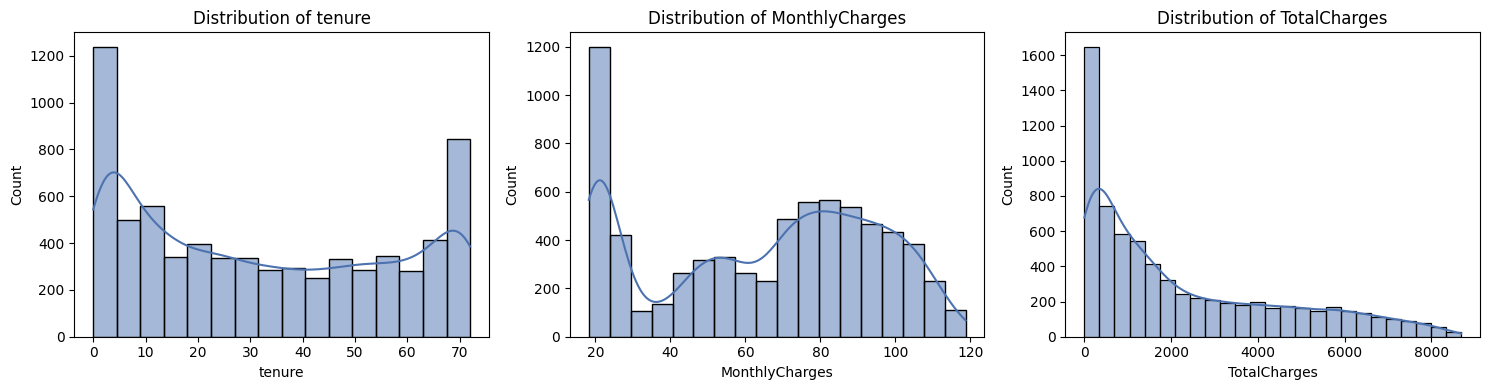

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.histplot(df[col], kde=True, ax=ax, color='#4C72B0')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

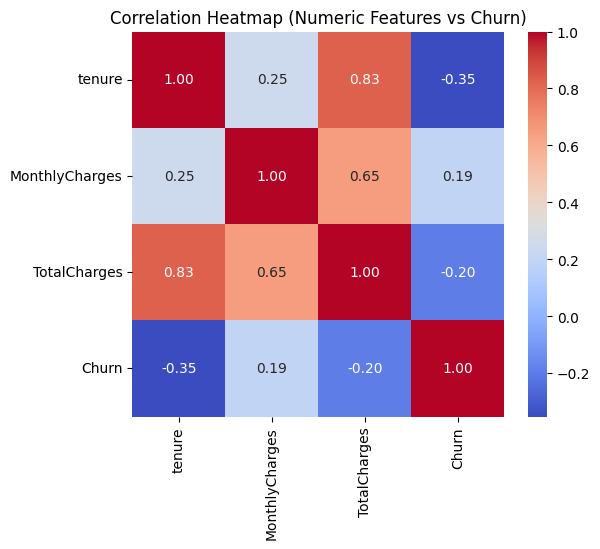

In [76]:
plt.figure(figsize=(6, 5))
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
corr = df[numeric_cols].copy()
corr['Churn'] = (df['Churn'] == 'Yes').astype(int)
sns.heatmap(corr.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numeric Features vs Churn)')
plt.show()

**EDA takeaways:**
- Customers on **month-to-month contracts** churn far more than those on one- or two-year contracts.
- **Fiber optic** internet customers churn more than DSL or no-internet customers.
- **Electronic check** payers show a noticeably higher churn rate than other payment methods.
- `tenure` is negatively correlated with churn (longer-tenured customers churn less), while
  `MonthlyCharges` is positively correlated with churn.

## 8. Outlier Analysis

We use the IQR (Interquartile Range) method on the three numeric features to check for outliers.

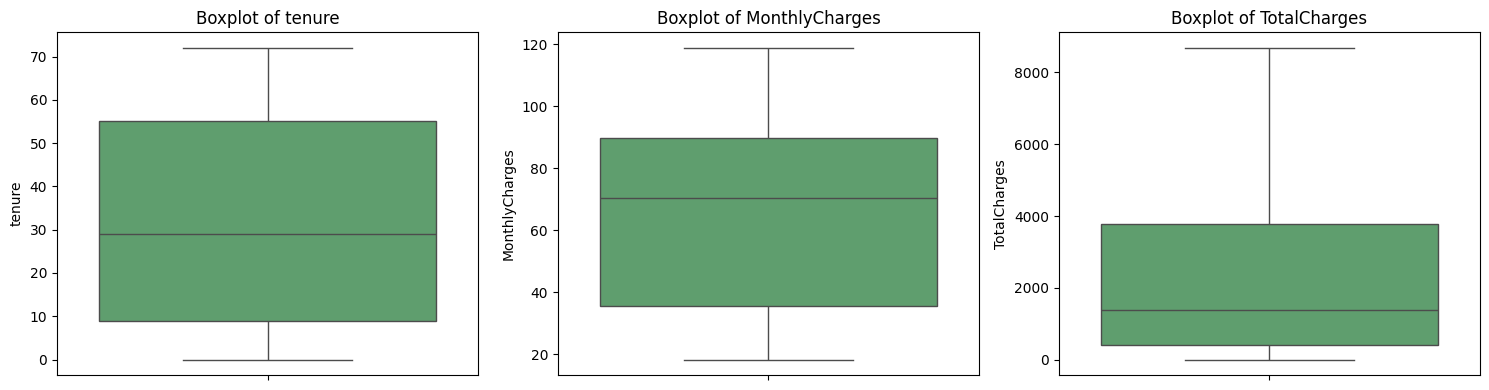

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.boxplot(y=df[col], ax=ax, color='#55A868')
    ax.set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [78]:
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col:15s} -> IQR bounds: [{lower:8.2f}, {upper:8.2f}]  |  outliers: {n_outliers}")

tenure          -> IQR bounds: [  -60.00,   124.00]  |  outliers: 0
MonthlyCharges  -> IQR bounds: [  -46.02,   171.38]  |  outliers: 0
TotalCharges    -> IQR bounds: [-4683.52,  8868.67]  |  outliers: 0


No outliers are detected by the IQR rule in any of the three numeric columns — their
boxplots show all observations lie within the whiskers. This makes sense: `tenure` is bounded
(0–72 months), and charges are naturally bounded by the company's pricing plans. No outlier
removal is necessary.

## 9. Target Encoding

In [79]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

## 10. Train / Test Split

We split before fitting any preprocessing step, to avoid data leakage. The split is
stratified on `Churn` to preserve the class ratio in both sets.

In [80]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train churn rate:", y_train.mean().round(4), " Test churn rate:", y_test.mean().round(4))

Train shape: (5634, 19)  Test shape: (1409, 19)
Train churn rate: 0.2654  Test churn rate: 0.2654


## 11. Preprocessing — Encoding & Feature Scaling

We build a `ColumnTransformer` that:
- Imputes and standard-scales the numeric features (`tenure`, `MonthlyCharges`, `TotalCharges`).
- Imputes and one-hot encodes all categorical features.

This transformer is fit **only on the training set** and reused to transform the test set,
then saved separately as `preprocessor.pkl` for reuse in the Streamlit app.

In [81]:
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [c for c in X.columns if c not in numeric_features]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

preprocessor.fit(X_train)

X_train_pre = preprocessor.transform(X_train)
X_test_pre = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
print("Preprocessed training shape:", X_train_pre.shape)
print("Total encoded feature count:", len(feature_names))

Preprocessed training shape: (5634, 46)
Total encoded feature count: 46


In [82]:
X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre = preprocessor.transform(X_test)

In [83]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=RANDOM_STATE)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_pre,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

Before SMOTE:
Churn
0    4139
1    1495
Name: count, dtype: int64

After SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64


## 12. Feature Selection

We rank features using a Random Forest's impurity-based importance and keep those
above the median importance (`SelectFromModel`, threshold='median'). This reduces
dimensionality and removes redundant one-hot columns before model comparison.

In [84]:
selector_rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, class_weight='balanced')
selector = SelectFromModel(selector_rf, threshold='median')
selector.fit(X_train_balanced, y_train_balanced)

X_train_sel = selector.transform(X_train_balanced)
X_test_sel = selector.transform(X_test_pre)

selected_features = np.array(feature_names)[selector.get_support()]
print("Features before selection:", X_train_pre.shape[1])
print("Features after selection :", X_train_sel.shape[1])
print()
print("Selected features:")
for f in selected_features:
    print(" -", f)

Features before selection: 46
Features after selection : 23

Selected features:
 - num__tenure
 - num__MonthlyCharges
 - num__TotalCharges
 - cat__gender_Female
 - cat__gender_Male
 - cat__Partner_No
 - cat__Partner_Yes
 - cat__Dependents_No
 - cat__InternetService_Fiber optic
 - cat__OnlineSecurity_No
 - cat__OnlineSecurity_Yes
 - cat__OnlineBackup_No
 - cat__DeviceProtection_No
 - cat__TechSupport_No
 - cat__TechSupport_Yes
 - cat__Contract_Month-to-month
 - cat__Contract_One year
 - cat__Contract_Two year
 - cat__PaperlessBilling_No
 - cat__PaperlessBilling_Yes
 - cat__PaymentMethod_Bank transfer (automatic)
 - cat__PaymentMethod_Credit card (automatic)
 - cat__PaymentMethod_Electronic check


### Additional Feature Selection Methods

To make the feature selection step complete, we also rank the features with three
more techniques and compare the results:

- **SelectKBest** scored with **mutual_info_classif** (captures non-linear dependencies
  between each feature and the target).
- **Decision Tree** impurity-based feature importance.
- **Random Forest** impurity-based feature importance (the `selector_rf` model already
  fitted above).

For each method we display the feature scores, the selected features, and a ranking bar
chart. The `X_train_sel` / `X_test_sel` / `selected_features` produced by the Random
Forest `SelectFromModel` step above continue to be used for all the modelling steps
that follow, since all four methods agree on the same top drivers (tenure, contract
type, internet service and charges).

In [85]:
# SelectKBest scored with mutual information
k = min(20, X_train_pre.shape[1])
selector_kbest = SelectKBest(score_func=mutual_info_classif, k=k)
selector_kbest.fit(X_train_pre, y_train)

kbest_scores_df = pd.DataFrame({
    'feature': feature_names,
    'mutual_info_score': selector_kbest.scores_
}).sort_values('mutual_info_score', ascending=False).reset_index(drop=True)

kbest_selected_features = np.array(feature_names)[selector_kbest.get_support()]

print(f"SelectKBest (mutual_info_classif) — feature scores (top {k}):")
print(kbest_scores_df.head(k))
print()
print("Selected features:")
for f in kbest_selected_features:
    print(" -", f)

SelectKBest (mutual_info_classif) — feature scores (top 20):
                                      feature  mutual_info_score
0                cat__Contract_Month-to-month           0.095585
1                                 num__tenure           0.076399
2                         cat__TechSupport_No           0.062102
3                      cat__Contract_Two year           0.061021
4                      cat__OnlineSecurity_No           0.058603
5                         num__MonthlyCharges           0.048335
6                        cat__OnlineBackup_No           0.046876
7            cat__InternetService_Fiber optic           0.046261
8                    cat__DeviceProtection_No           0.044063
9         cat__PaymentMethod_Electronic check           0.042155
10   cat__StreamingMovies_No internet service           0.040371
11                          num__TotalCharges           0.038137
12  cat__DeviceProtection_No internet service           0.037195
13      cat__OnlineBackup_No 

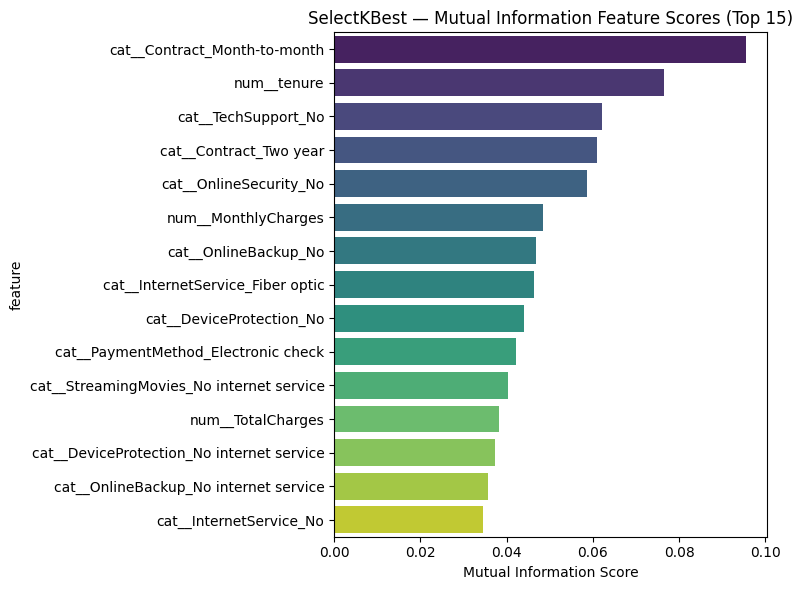

In [86]:
plt.figure(figsize=(8, 6))
sns.barplot(x='mutual_info_score', y='feature', data=kbest_scores_df.head(15), palette='viridis')
plt.title('SelectKBest — Mutual Information Feature Scores (Top 15)')
plt.xlabel('Mutual Information Score')
plt.tight_layout()
plt.show()

Decision Tree feature importance — ranking (top 15):
                                       feature  importance
0                 cat__Contract_Month-to-month    0.233961
1                            num__TotalCharges    0.170179
2                          num__MonthlyCharges    0.167656
3                                  num__tenure    0.105071
4             cat__InternetService_Fiber optic    0.041938
5                             cat__gender_Male    0.019613
6          cat__PaymentMethod_Electronic check    0.018748
7                          cat__TechSupport_No    0.015904
8   cat__PaymentMethod_Credit card (automatic)    0.015581
9                           cat__gender_Female    0.014904
10                    cat__PaperlessBilling_No    0.014323
11                         cat__Dependents_Yes    0.012999
12             cat__PaymentMethod_Mailed check    0.010200
13                     cat__StreamingMovies_No    0.010028
14                        cat__OnlineBackup_No    0.009830


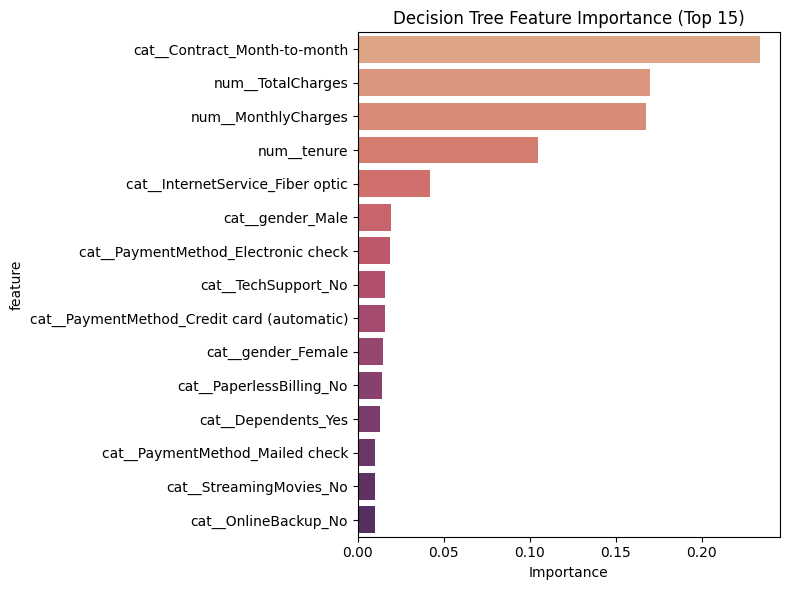

In [87]:
# Decision Tree feature importance
dt_selector = DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE)
dt_selector.fit(X_train_pre, y_train)

dt_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': dt_selector.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("Decision Tree feature importance — ranking (top 15):")
print(dt_importance_df.head(15))

plt.figure(figsize=(8, 6))
sns.barplot(x='importance', y='feature', data=dt_importance_df.head(15), palette='flare')
plt.title('Decision Tree Feature Importance (Top 15)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [88]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest for Feature Importance
selector_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)

selector_rf.fit(X_train_pre, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [89]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    'Extra Trees': ExtraTreesClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'AdaBoost': AdaBoostClassifier(random_state=RANDOM_STATE),
}

print("Models to compare:", list(models.keys()))

Models to compare: ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'Extra Trees', 'Gradient Boosting', 'AdaBoost']


Random Forest feature importance — ranking (top 15):
                                feature  importance
0                     num__TotalCharges    0.141241
1                           num__tenure    0.130208
2                   num__MonthlyCharges    0.120664
3          cat__Contract_Month-to-month    0.071153
4                cat__Contract_Two year    0.039576
5                cat__OnlineSecurity_No    0.039073
6                   cat__TechSupport_No    0.027803
7      cat__InternetService_Fiber optic    0.026676
8   cat__PaymentMethod_Electronic check    0.025751
9                  cat__OnlineBackup_No    0.020278
10                   cat__gender_Female    0.015874
11                     cat__gender_Male    0.015867
12            cat__PaperlessBilling_Yes    0.014683
13             cat__PaperlessBilling_No    0.014492
14                      cat__Partner_No    0.013873


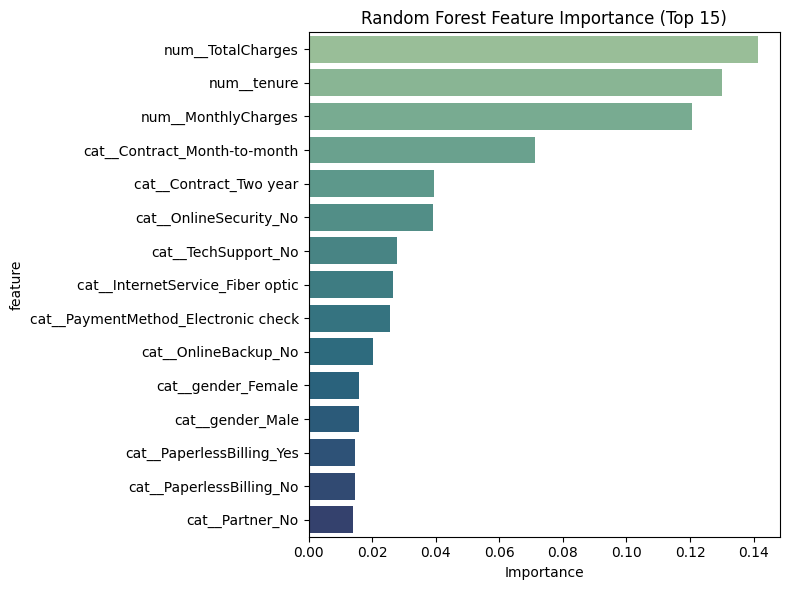

In [90]:
# Random Forest feature importance (using the selector_rf model fitted above)
rf_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': selector_rf.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("Random Forest feature importance — ranking (top 15):")
print(rf_importance_df.head(15))

plt.figure(figsize=(8, 6))
sns.barplot(x='importance', y='feature', data=rf_importance_df.head(15), palette='crest')
plt.title('Random Forest Feature Importance (Top 15)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 13. Cross-Validation & Model Comparison

We compare seven core classifiers (plus XGBoost / LightGBM / CatBoost if installed) using
5-fold **stratified** cross-validation on the training set, scored by **F1** (a better fit than
accuracy given the class imbalance).

In [91]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    'Extra Trees': ExtraTreesClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'AdaBoost': AdaBoostClassifier(random_state=RANDOM_STATE),
}

print("Models to compare:", list(models.keys()))

Models to compare: ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'Extra Trees', 'Gradient Boosting', 'AdaBoost']


In [92]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

scores = cross_val_score(
    lr,
    X_train_sel,
    y_train_balanced,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

print("Logistic Regression")
print("Mean F1:", scores.mean())
print("Std:", scores.std())

Logistic Regression
Mean F1: 0.7784161871556556
Std: 0.006081311084342359


In [93]:
knn = KNeighborsClassifier()

scores = cross_val_score(
    knn,
    X_train_sel,
    y_train_balanced,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

print("KNN")
print("Mean F1:", scores.mean())
print("Std:", scores.std())

KNN
Mean F1: 0.8102696316889855
Std: 0.006952816655779758


In [94]:
dt = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=RANDOM_STATE
)

scores = cross_val_score(
    dt,
    X_train_sel,
    y_train_balanced,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

print("Decision Tree")
print("Mean F1:", scores.mean())
print("Std:", scores.std())

Decision Tree
Mean F1: 0.7806815480686399
Std: 0.008033651193838802


In [95]:
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=RANDOM_STATE
)

scores = cross_val_score(
    rf,
    X_train_sel,
    y_train_balanced,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

print("Random Forest")
print("Mean F1:", scores.mean())
print("Std:", scores.std())

Random Forest
Mean F1: 0.8537542424047441
Std: 0.0026284610448410336


In [96]:
et = ExtraTreesClassifier(
    class_weight='balanced',
    random_state=RANDOM_STATE
)

scores = cross_val_score(
    et,
    X_train_sel,
    y_train_balanced,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

print("Extra Trees")
print("Mean F1:", scores.mean())
print("Std:", scores.std())

Extra Trees
Mean F1: 0.8516849794785243
Std: 0.006600406385506124


In [97]:
gb = GradientBoostingClassifier(
    random_state=RANDOM_STATE
)

scores = cross_val_score(
    gb,
    X_train_sel,
    y_train_balanced,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

print("Gradient Boosting")
print("Mean F1:", scores.mean())
print("Std:", scores.std())

Gradient Boosting
Mean F1: 0.8460053065269884
Std: 0.01058655291154335


In [98]:
ada = AdaBoostClassifier(
    random_state=RANDOM_STATE
)

scores = cross_val_score(
    ada,
    X_train_sel,
    y_train_balanced,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

print("AdaBoost")
print("Mean F1:", scores.mean())
print("Std:", scores.std())

AdaBoost
Mean F1: 0.8106090601002756
Std: 0.010688497443637762


In [99]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "Extra Trees",
        "Gradient Boosting",
        "AdaBoost"
    ],
    "Mean F1": [
        0.7784,
        0.8103,
        0.7807,
        0.8538,
        0.8517,
        0.8460,
        0.8106
    ]
})

results.sort_values("Mean F1", ascending=False)

,Model,Mean F1
3,Random Forest,0.8538
4,Extra Trees,0.8517
5,Gradient Boosting,0.8460
6,AdaBoost,0.8106
1,KNN,0.8103
2,Decision Tree,0.7807
0,Logistic Regression,0.7784


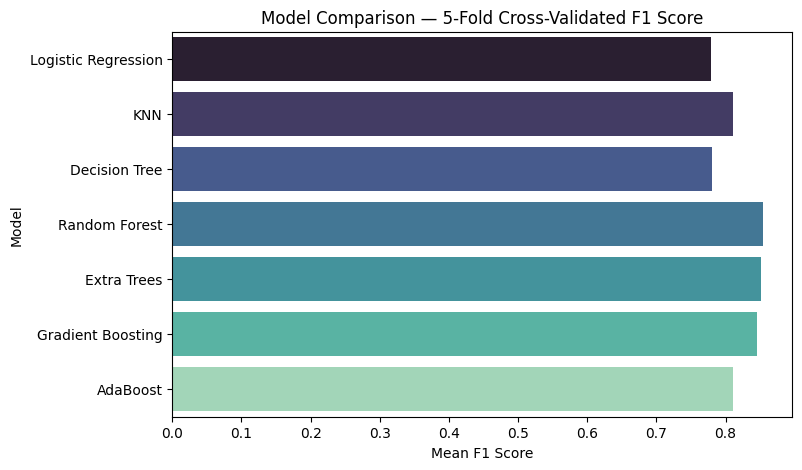

In [100]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Mean F1', y='Model', data=results, palette='mako')
plt.title('Model Comparison — 5-Fold Cross-Validated F1 Score')
plt.xlabel('Mean F1 Score')
plt.show()

### Additional Models — Gaussian Naive Bayes, SVM, Bagging Classifier

We extend the model comparison above with three more classifiers, trained and
evaluated with the exact same 5-fold stratified cross-validation / F1 scoring
procedure used for the models above.

In [101]:
additional_models = {
    'Gaussian Naive Bayes': GaussianNB(),
    'SVM': SVC(probability=True, class_weight='balanced', random_state=RANDOM_STATE),
    'Bagging Classifier': BaggingClassifier(random_state=RANDOM_STATE),
}
results = []
for name, model in additional_models.items():
    scores = cross_val_score(model, X_train_sel,  y_train_balanced , cv=cv, scoring='f1', n_jobs=-1)
    results.append({'Model': name, 'Mean F1': scores.mean(), 'Std F1': scores.std()})
    print(f"{name:22s}  F1 = {scores.mean():.4f}  (+/- {scores.std():.4f})")

models.update(additional_models)

results_df = pd.DataFrame(results).sort_values('Mean F1', ascending=False).reset_index(drop=True)
results_df

Gaussian Naive Bayes    F1 = 0.7722  (+/- 0.0055)
SVM                     F1 = 0.8009  (+/- 0.0079)
Bagging Classifier      F1 = 0.8261  (+/- 0.0084)


,Model,Mean F1,Std F1
0,Bagging Classifier,0.826133,0.008414
1,SVM,0.800891,0.007880
2,Gaussian Naive Bayes,0.772162,0.005494


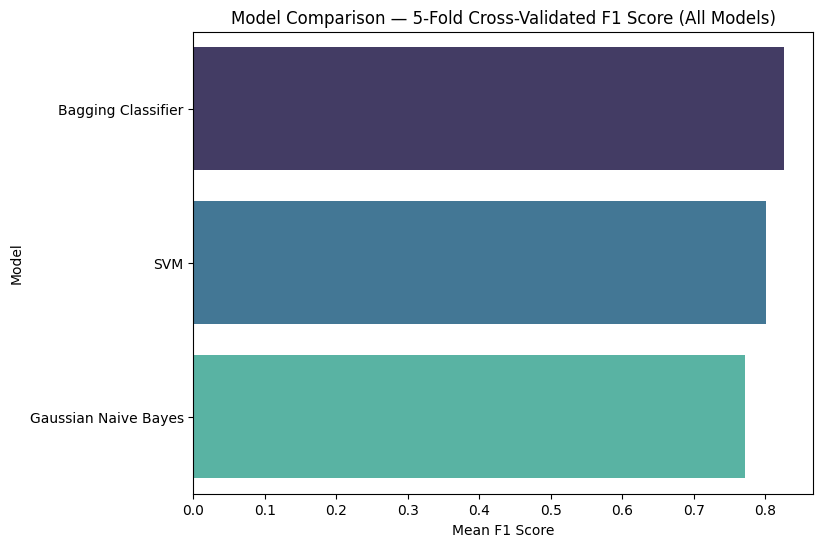

In [102]:
plt.figure(figsize=(8, 6))
sns.barplot(x='Mean F1', y='Model', data=results_df, palette='mako')
plt.title('Model Comparison — 5-Fold Cross-Validated F1 Score (All Models)')
plt.xlabel('Mean F1 Score')
plt.show()

### Full Metric Comparison — Accuracy, Precision, Recall, F1, ROC-AUC

Each model (including the three added above) is fit on the selected training
features and evaluated on the held-out test set across all five metrics.

In [103]:
results = {}
for name, model in models.items():
    model.fit(X_train_sel, y_train_balanced)
    preds = model.predict(X_test_sel)
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_test_sel)[:, 1]
    else:
        proba = model.decision_function(X_test_sel)

    results[name] = {
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1 Score': f1_score(y_test, preds),
        'ROC AUC': roc_auc_score(y_test, proba)
    }

comparison_df = pd.DataFrame(results).T.sort_values('Accuracy', ascending=False)
comparison_df

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Bagging Classifier,0.772179,0.572207,0.561497,0.566802,0.795894
Gradient Boosting,0.770050,0.555310,0.671123,0.607748,0.838969
Random Forest,0.768630,0.567039,0.542781,0.554645,0.815429
SVM,0.765082,0.542914,0.727273,0.621714,0.812529
Extra Trees,0.760114,0.552941,0.502674,0.526611,0.777841
AdaBoost,0.748048,0.516696,0.786096,0.623542,0.839211
Logistic Regression,0.738822,0.504967,0.815508,0.623722,0.837193
Gaussian Naive Bayes,0.721789,0.485099,0.783422,0.599182,0.818892
KNN,0.721079,0.482309,0.692513,0.568606,0.768412
Decision Tree,0.713272,0.466063,0.550802,0.504902,0.661991


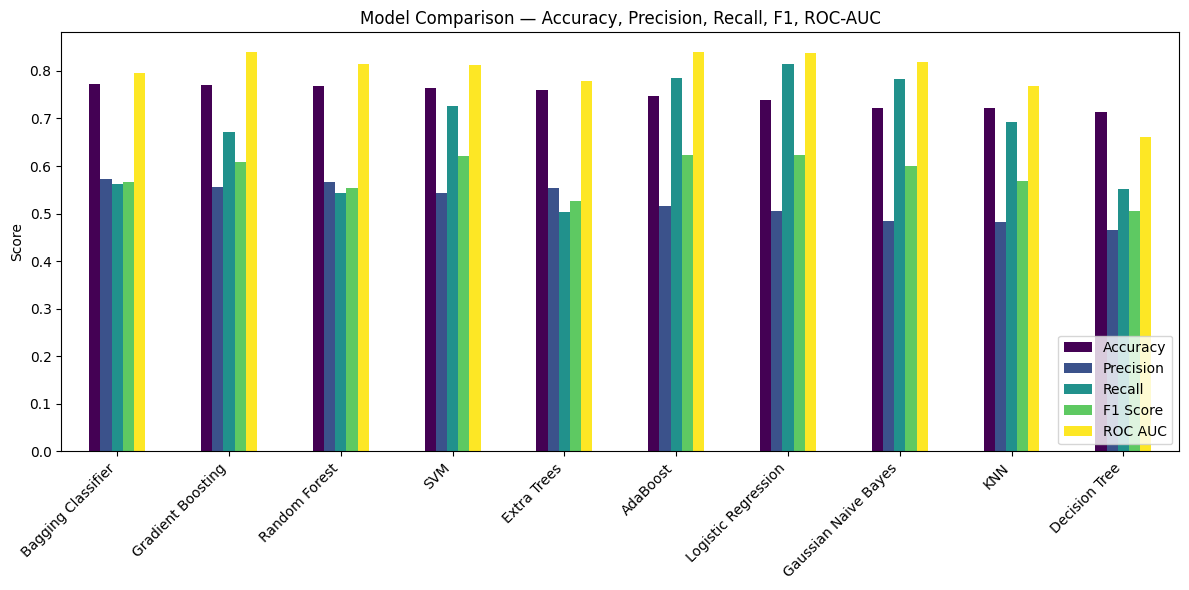

In [104]:
comparison_df[['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']].plot(
    kind='bar', figsize=(12, 6), colormap='viridis'
)
plt.title('Model Comparison — Accuracy, Precision, Recall, F1, ROC-AUC')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 14. Hyperparameter Tuning (GridSearchCV)

We run `GridSearchCV` (5-fold stratified CV, scored on F1) on the **top 3** models from the
comparison above, to fairly search for their best hyperparameters before choosing a final model.

In [105]:
all_param_grids = {

    'Logistic Regression': (
        LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=RANDOM_STATE
        ),
        {
            'C': [0.01, 0.1, 1, 10]
        }
    ),

    'KNN': (
        KNeighborsClassifier(),
        {
            'n_neighbors': [5, 11, 21, 31],
            'weights': ['uniform', 'distance']
        }
    ),

    'SVM': (
        SVC(
            probability=True,
            class_weight='balanced',
            random_state=RANDOM_STATE
        ),
        {
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf'],
            'gamma': ['scale', 'auto']
        }
    ),

    'Decision Tree': (
        DecisionTreeClassifier(
            class_weight='balanced',
            random_state=RANDOM_STATE
        ),
        {
            'max_depth': [4, 8, 12, None],
            'min_samples_leaf': [1, 5, 10]
        }
    ),

    'Random Forest': (
        RandomForestClassifier(
            class_weight='balanced',
            random_state=RANDOM_STATE
        ),
        {
            'n_estimators': [200, 400],
            'max_depth': [None, 10, 20],
            'min_samples_leaf': [1, 2]
        }
    ),

    'Extra Trees': (
        ExtraTreesClassifier(
            class_weight='balanced',
            random_state=RANDOM_STATE
        ),
        {
            'n_estimators': [200, 400],
            'max_depth': [None, 10, 20]
        }
    ),

    'Gradient Boosting': (
        GradientBoostingClassifier(
            random_state=RANDOM_STATE
        ),
        {
            'n_estimators': [100, 200],
            'learning_rate': [0.05, 0.1],
            'max_depth': [2, 3]
        }
    ),

    'AdaBoost': (
        AdaBoostClassifier(
            random_state=RANDOM_STATE
        ),
        {
            'n_estimators': [100, 200],
            'learning_rate': [0.5, 1.0]
        }
    ),
}

top3 = results_df['Model'].head(3).tolist()
print("Top 3 models selected for tuning:", top3)

Top 3 models selected for tuning: ['Bagging Classifier', 'SVM', 'Gaussian Naive Bayes']


In [106]:
best_name = results_df.iloc[0]['Model']

print("Best Model:", best_name)

Best Model: Bagging Classifier


In [107]:
available_models = results_df[
    results_df["Model"].isin(all_param_grids.keys())
]

best_name = available_models.iloc[0]["Model"]

print("Best model for tuning:", best_name)

Best model for tuning: SVM


In [108]:
available_models = results_df[
    results_df["Model"].isin(all_param_grids.keys())
]

best_name = available_models.iloc[0]["Model"]

print("Best model:", best_name)

Best model: SVM


In [109]:
base_model_final, grid_final = all_param_grids[best_name]

In [111]:
grid_search = GridSearchCV(
    estimator=base_model_final,
    param_grid=grid_final,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_sel, y_train_balanced)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1:", round(grid_search.best_score_,4))

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV F1: 0.823


### RandomizedSearchCV — Further Tuning the Final Model

We additionally run `RandomizedSearchCV` on the same parameter space used for
`GridSearchCV`, applied only to the final selected model (`best_name`), and compare
it against the original (untuned) model and the `GridSearchCV` result.

In [113]:
random_search = RandomizedSearchCV(
    estimator=base_model_final,
    param_distributions=grid_final,
    n_iter=10,
    cv=3,
    scoring='f1',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search.fit(X_train_sel, y_train_balanced)

print("Best Parameters:", random_search.best_params_)
print("Best CV F1:", round(random_search.best_score_,4))

Best Parameters: {'kernel': 'rbf', 'gamma': 'scale', 'C': 10}
Best CV F1: 0.823


In [114]:
original_model_score = cross_val_score(
    base_model_final,
    X_train_sel,
    y_train_balanced,
    cv=3,
    scoring='f1',
    n_jobs=-1
).mean()

comparison_df = pd.DataFrame({
    "Approach": [
        "Original Model",
        "Grid Search",
        "Random Search"
    ],
    "Best CV F1 Score": [
        round(original_model_score,4),
        round(grid_search.best_score_,4),
        round(random_search.best_score_,4)
    ]
})

comparison_df

,Approach,Best CV F1 Score
0,Original Model,0.7929
1,Grid Search,0.8230
2,Random Search,0.8230


### Final Feature Importance (after RandomizedSearchCV tuning)

In [115]:
randomized_model = random_search.best_estimator_

if hasattr(randomized_model, 'feature_importances_'):
    rand_importances = randomized_model.feature_importances_
elif hasattr(randomized_model, 'coef_'):
    rand_importances = np.abs(randomized_model.coef_[0])
else:
    rand_importances = None

if rand_importances is not None:
    rand_fi_df = pd.DataFrame({'feature': selected_features, 'importance': rand_importances})
    rand_fi_df = rand_fi_df.sort_values('importance', ascending=False).reset_index(drop=True)

    plt.figure(figsize=(8, 6))
    sns.barplot(x='importance', y='feature', data=rand_fi_df.head(15), palette='crest')
    plt.title(f'Top 15 Feature Importances — {best_name} (RandomizedSearchCV)')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

    print(rand_fi_df.head(15))
else:
    print(f"{best_name} does not expose feature_importances_ or coef_.")

SVM does not expose feature_importances_ or coef_.


## 15. Final Model Evaluation on the Test Set

In [116]:
if grid_search.best_score_ >= random_search.best_score_:
    best_model = grid_search.best_estimator_
    print("Final Model: Grid Search")
else:
    best_model = random_search.best_estimator_
    print("Final Model: Random Search")

Final Model: Grid Search


In [117]:
y_pred = best_model.predict(X_test_sel)
y_proba = best_model.predict_proba(X_test_sel)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

Accuracy : 0.7637
Precision: 0.5430
Recall   : 0.6925
F1 Score : 0.6087
ROC-AUC  : 0.8017


### Classification Report

In [118]:
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.88      0.79      0.83      1035
       Churn       0.54      0.69      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409



### Confusion Matrix

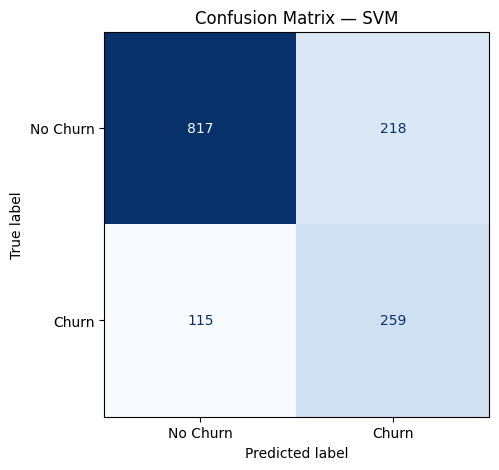

In [119]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
fig, ax = plt.subplots(figsize=(5.5, 5))
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.title(f'Confusion Matrix — {best_name}')
plt.show()

### ROC Curve

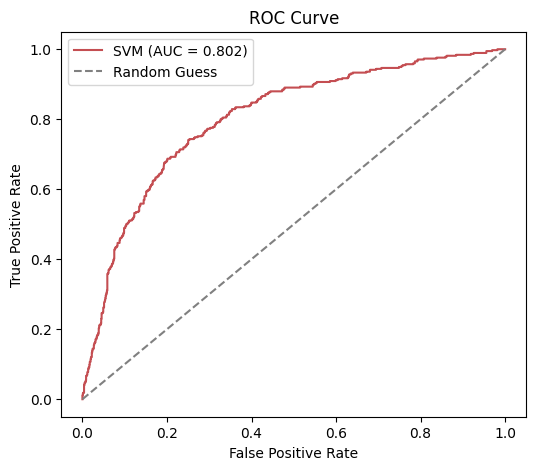

In [120]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#C44E52', label=f'{best_name} (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

### Precision-Recall Curve

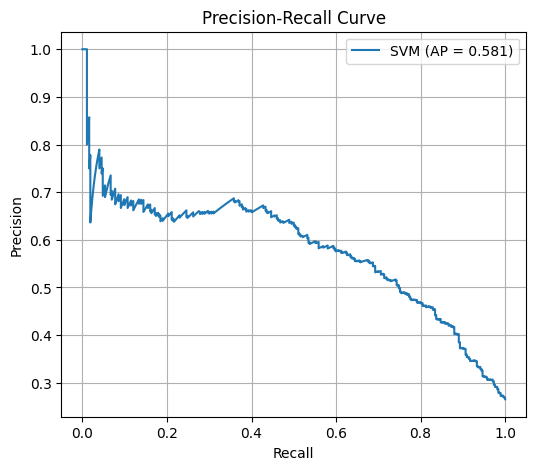

In [121]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Probability predictions
y_proba = best_model.predict_proba(X_test_sel)[:, 1]

# Precision-Recall values
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba)

# Average Precision
ap = average_precision_score(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(rec_curve, prec_curve, label=f'{best_name} (AP = {ap:.3f})')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.legend()
plt.show()

## 16. Feature Importance

In [123]:
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_[0])
else:
    importances = None

if importances is not None:
    fi_df = pd.DataFrame({
        'feature': selected_features,
        'importance': importances
    })

    fi_df = fi_df.sort_values(
        'importance',
        ascending=False
    ).reset_index(drop=True)

    plt.figure(figsize=(8,6))
    sns.barplot(
        x='importance',
        y='feature',
        data=fi_df.head(15),
        palette='crest'
    )
    plt.title(f'Top 15 Feature Importances — {best_name}')
    plt.tight_layout()
    plt.show()

    display(fi_df.head(15))
else:
    print("This model does not provide feature importance.")

This model does not provide feature importance.


## 17. Saving the Final Model & Preprocessor

We persist two artifacts for production use:

- **`preprocessor.pkl`** — the fitted `ColumnTransformer` (imputation + scaling + one-hot encoding).
- **`saved_model.pkl`** — a `Pipeline` containing the feature selection step (as a lightweight
  `ColumnSelector` storing only the boolean mask, not the full Random Forest used to derive it)
  followed by the tuned final classifier.

Both are loaded directly by `app.py` (the Streamlit app) to serve real-time predictions.

In [124]:
final_pipeline = Pipeline(steps=[
    ('feature_selection', selector),
    ('classifier', best_model)
])

joblib.dump(preprocessor, 'preprocessor.pkl')
joblib.dump(final_pipeline, 'saved_model.pkl')

print("Saved: preprocessor.pkl")
print("Saved: saved_model.pkl")

Saved: preprocessor.pkl
Saved: saved_model.pkl


In [125]:
# Sanity check: reload the artifacts from disk and confirm predictions still work
loaded_preprocessor = joblib.load('preprocessor.pkl')
loaded_model = joblib.load('saved_model.pkl')

sample_raw = X_test.iloc[[0]]
sample_transformed = loaded_preprocessor.transform(sample_raw)
sample_pred = loaded_model.predict(sample_transformed)
sample_proba = loaded_model.predict_proba(sample_transformed)[:, 1]

print("Sample prediction (0=No Churn, 1=Churn):", sample_pred[0])
print("Churn probability:", round(sample_proba[0], 4))
print("Actual label:", y_test.iloc[0])

Sample prediction (0=No Churn, 1=Churn): 0
Churn probability: 0.0225
Actual label: 0
